1. Мы генерируем множество точек внутри квадрата с помощью равно-
мерного распределения.
2. Для каждой точки проверяем, попала ли она внутрь окружности.
3. Подсчитываем долю точек, попавших в окружность, по сравнению с
общим числом точек.
4. Используя это соотношение, приближённо вычисляем значение числа
π.

/tmp/ipykernel_11385/2460150358.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


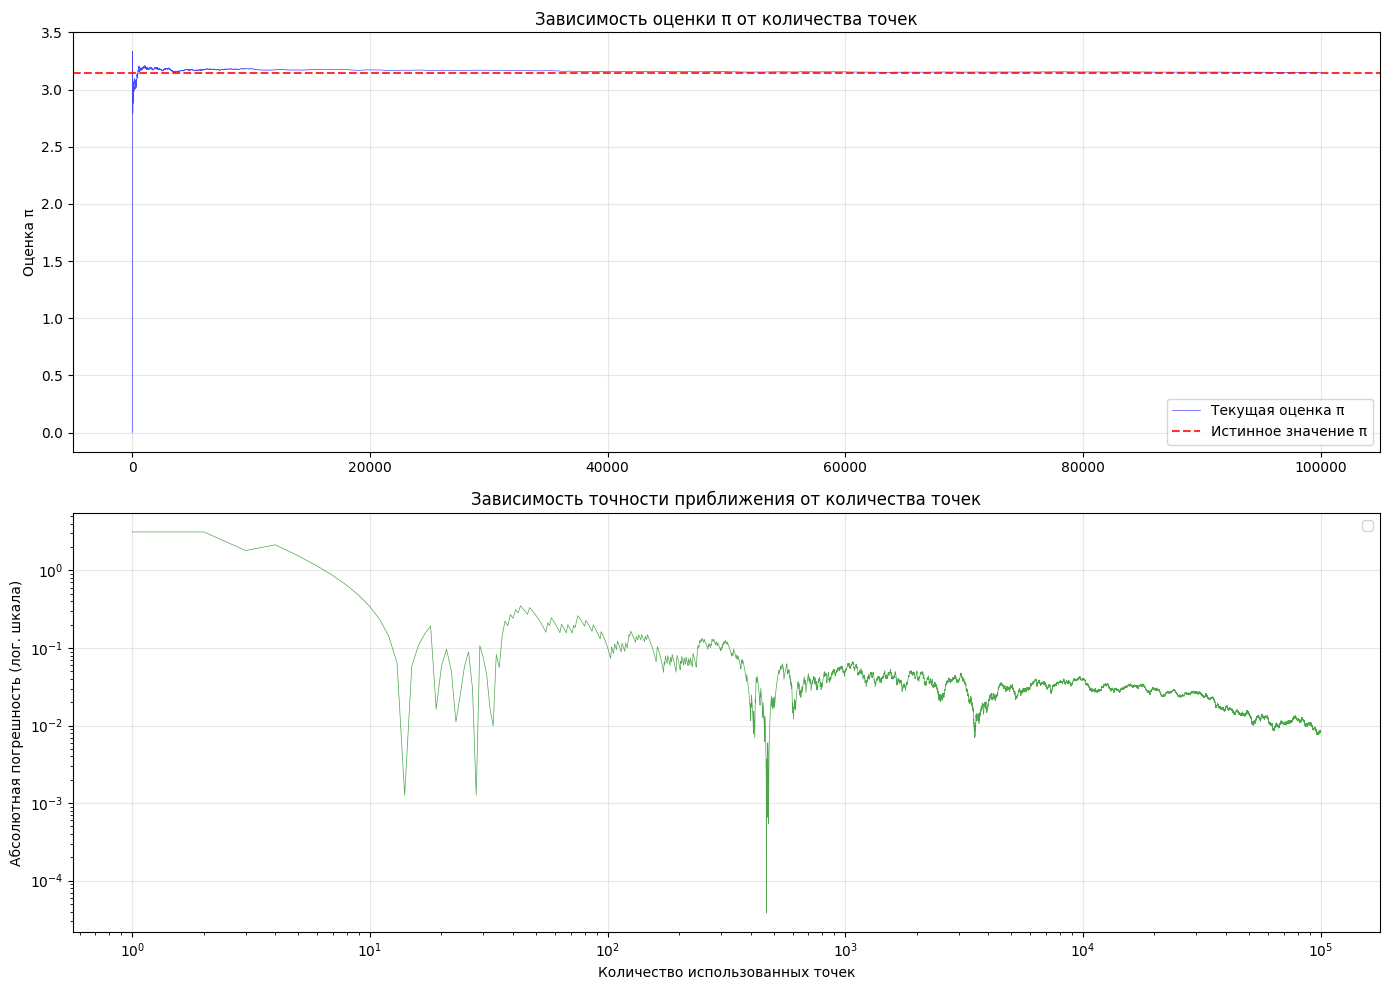

Результаты эксперимента:
Всего точек: 100,000
Точек внутри окружности: 78,757
Финальная оценка π: 3.1502800
Истинное значение π: 3.1415927
Абсолютная погрешность: 0.0086873
Относительная ошибка: 0.2765%


In [5]:
import random
import math
import matplotlib.pyplot as plt
import time

seed = int(time.time_ns())

def random_gen():
    global seed
    M = 2**64
    a = 6364136223846793005
    b = 1442695040888963407

    # Xn+1 = aXn + b (mod M).
    seed = (a * seed + b) % M
    return seed / M


def monte_carlo_simulation(total_points):
    points_inside = 0
    pi_estimates = []
    accuracy_values = []

    for point_num in range(1, total_points + 1):
        x = random_gen()
        y = random_gen()

        if(x - 0.5)**2 + (y - 0.5)**2 <= 0.25:
            points_inside += 1

        # пересчитываем оценку π и точность после каждой точки
        current_pi = 4 * points_inside / point_num
        current_accuracy = abs(math.pi - current_pi)

        pi_estimates.append(current_pi)
        accuracy_values.append(current_accuracy)

    return pi_estimates, accuracy_values, points_inside

TOTAL_POINTS = 100000

pi_estimates, accuracy_metrics, points_inside = monte_carlo_simulation(TOTAL_POINTS)

plt.figure(figsize=(14, 10))


# показывает как меняется оценка π по мере добавления новых точек
# слва неточно потому что точек мало потом выравнивается
plt.subplot(2, 1, 1)
plt.plot(range(1, TOTAL_POINTS + 1), pi_estimates, 
         'blue', linewidth=0.5, alpha=0.7, label='Текущая оценка π')
plt.axhline(y=math.pi, color='red', linestyle='--', 
            alpha=0.8, linewidth=1.5, label='Истинное значение π')
plt.ylabel('Оценка π')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Зависимость оценки π от количества точек')

# показывает как уменьшается ошибка оценки числа π при добвалении новых точек
# линия - абсолютная погрещость между π и оценкой
plt.subplot(2, 1, 2)
plt.loglog(range(1, TOTAL_POINTS + 1), accuracy_metrics, 
           'green', linewidth=0.5, alpha=0.7)
plt.xlabel('Количество использованных точек')
plt.ylabel('Абсолютная погрешность (лог. шкала)')
plt.grid(True, alpha=0.3)
plt.title('Зависимость точности приближения от количества точек')


plt.legend()
plt.tight_layout()
plt.show()

final_pi = pi_estimates[-1]
print("Результаты эксперимента:")
print(f"Всего точек: {TOTAL_POINTS:,}")
print(f"Точек внутри окружности: {points_inside:,}")
print(f"Финальная оценка π: {final_pi:.7f}")
print(f"Истинное значение π: {math.pi:.7f}")
print(f"Абсолютная погрешность: {abs(math.pi - final_pi):.7f}")
print(f"Относительная ошибка: {abs(math.pi - final_pi)/math.pi*100:.4f}%")

Генератор случайных чисел

In [ ]:
import time

def random_gen():
    M = 2**64
    a = 6364136223846793005
    b = 1442695040888963407
    seed = int(time.time_ns())

    # Xn+1 = aXn + b (mod M).

    for i in range(100):
        seed = (a*seed+b)%M 
    return seed/M
#print(seed/M)

0.47165368200563285
